1. Importing libraries

In [3]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns


2. Loading dataset

In [4]:
df = pd.read_csv(r"C:\Users\RYAN T\Documents\archive (2)\iphone_sales_dataset.csv", encoding='latin1')

3. Data Inspection & Cleaning

In [6]:
print("=" * 60)
print("SHAPE & MEMORY")
print("=" * 60)
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print(f"Approx. memory (KiB): {df.memory_usage(deep=True).sum() / 1024:.2f}")

print("\n" + "=" * 60)
print("DTYPES")
print("=" * 60)
print(df.dtypes)

print("\n" + "=" * 60)
print("HEAD / TAIL")
print("=" * 60)
display(df.head(3))
display(df.tail(3))

print("\n" + "=" * 60)
print("MISSING VALUES PER COLUMN")
print("=" * 60)
miss = df.isna().sum()
print(miss if miss.any() else "No missing values.")

print("\n" + "=" * 60)
print("DUPLICATE ROWS")
print("=" * 60)
print(f"Fully duplicate rows: {df.duplicated().sum()}")

numeric_cols = ["Quantity", "Price"]
print("\n" + "=" * 60)
print("DESCRIBE (Quantity, Price)")
print("=" * 60)
print(df[numeric_cols].describe())

# Treat Price as unit price; line revenue = units * unit price
df["Line_Revenue"] = df["Quantity"] * df["Price"]

print("\n" + "=" * 60)
print("LINE REVENUE (Quantity * Price)")
print("=" * 60)
print(f"Total Line_Revenue: {df['Line_Revenue'].sum():,.2f}")
print(f"Mean per order: {df['Line_Revenue'].mean():,.2f}")

cat_cols = ["Country", "iPhone_Model", "Storage", "Color", "Payment_Method"]
print("\n" + "=" * 60)
print("VALUE COUNTS")
print("=" * 60)
for col in cat_cols:
    print(f"\n--- {col} ---")
    print(df[col].value_counts())

print("\n" + "=" * 60)
print("CORRELATION")
print("=" * 60)
print(df[["Quantity", "Price", "Line_Revenue"]].corr(numeric_only=True))

SHAPE & MEMORY
Rows: 100, Columns: 11
Approx. memory (KiB): 47.58

DTYPES
Order_ID           int64
Customer_Name     object
Country           object
iPhone_Model      object
Storage           object
Color             object
Quantity           int64
Price              int64
Sale_Date         object
Payment_Method    object
Line_Revenue       int64
dtype: object

HEAD / TAIL


,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method,Line_Revenue
0,1001,Customer_1,USA,iPhone 13,256GB,Purple,5,1817,2025-05-01,Debit Card,9085
1,1002,Customer_2,Canada,iPhone 12,256GB,Blue,1,998,2025-03-05,PayPal,998
2,1003,Customer_3,Canada,iPhone 15 Pro Max,512GB,Black,5,876,2025-01-25,Credit Card,4380


,Order_ID,Customer_Name,Country,iPhone_Model,Storage,Color,Quantity,Price,Sale_Date,Payment_Method,Line_Revenue
97,1098,Customer_98,UK,iPhone 15 Pro Max,512GB,White,4,1125,2025-01-08,Debit Card,4500
98,1099,Customer_99,Germany,iPhone 15 Pro Max,512GB,Purple,5,1540,2025-02-04,Debit Card,7700
99,1100,Customer_100,UK,iPhone 15,512GB,Blue,3,1549,2025-03-28,Debit Card,4647



MISSING VALUES PER COLUMN
No missing values.

DUPLICATE ROWS
Fully duplicate rows: 0

DESCRIBE (Quantity, Price)
         Quantity        Price
count  100.000000   100.000000
mean     3.330000  1468.750000
std      1.484295   388.367637
min      1.000000   718.000000
25%      2.000000  1123.750000
50%      3.000000  1571.500000
75%      5.000000  1794.250000
max      5.000000  1992.000000

LINE REVENUE (Quantity * Price)
Total Line_Revenue: 494,453.00
Mean per order: 4,944.53

VALUE COUNTS

--- Country ---
Country
USA         22
UK          22
Canada      18
UAE         17
Germany     11
Pakistan    10
Name: count, dtype: int64

--- iPhone_Model ---
iPhone_Model
iPhone 14 Pro        24
iPhone 15 Pro Max    22
iPhone 15            16
iPhone 13            14
iPhone 12            13
iPhone 14            11
Name: count, dtype: int64

--- Storage ---
Storage
256GB    38
128GB    34
512GB    28
Name: count, dtype: int64

--- Color ---
Color
Blue      25
White     22
Purple    19
Red       1

In [25]:
df['Sale_Date']=pd.to_datetime(df['Sale_Date'])

4. Explaratoty Data Analysis(EDA)

Correlation Matrix

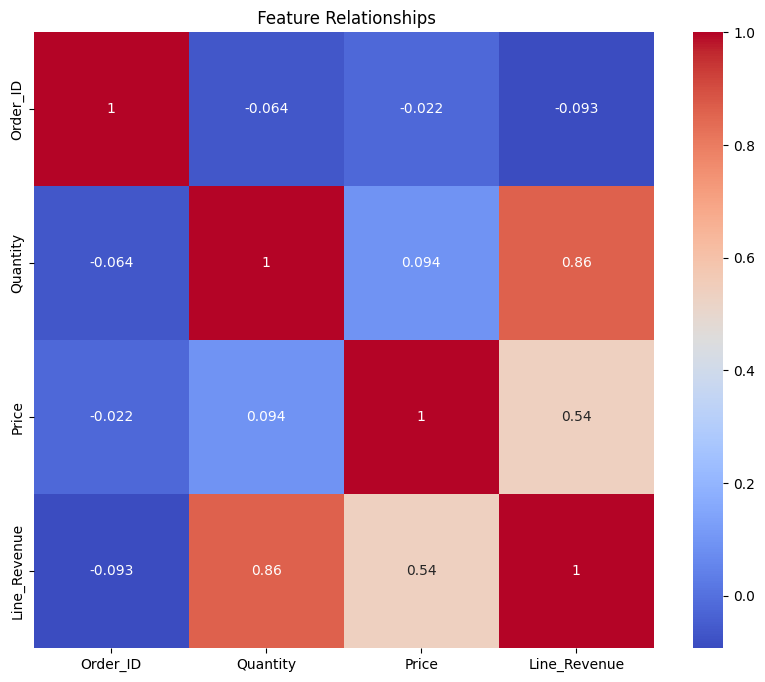

In [10]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title(" Feature Relationships")
plt.show()

STRONG POSITIVE CORRELATION BETWEEN REVENUE AND BOTH PRICE AND QUANTITY, THAT IS WHEN QUANTITY INCREASES, REVENUE INCREASES 

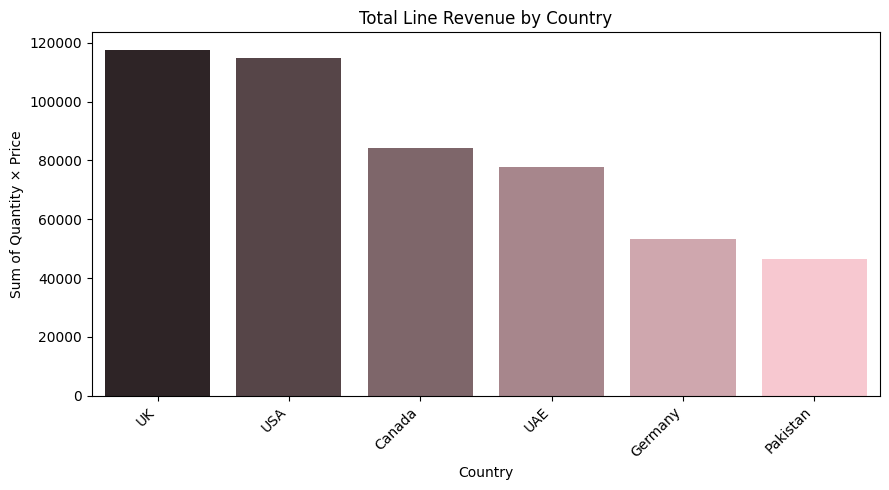

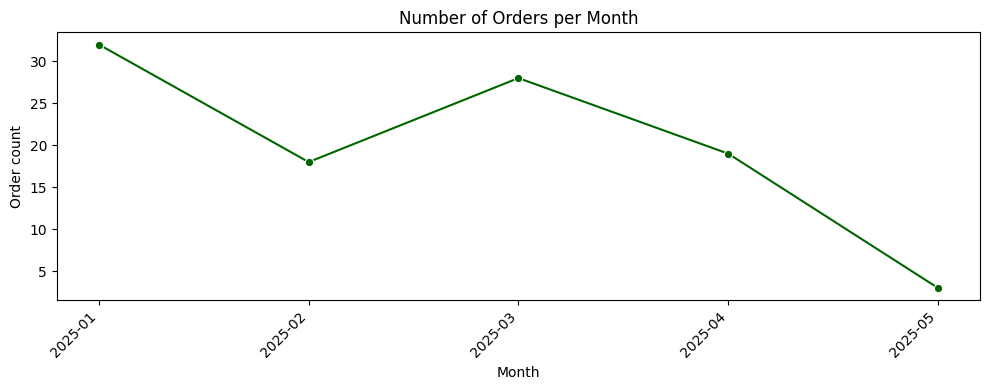

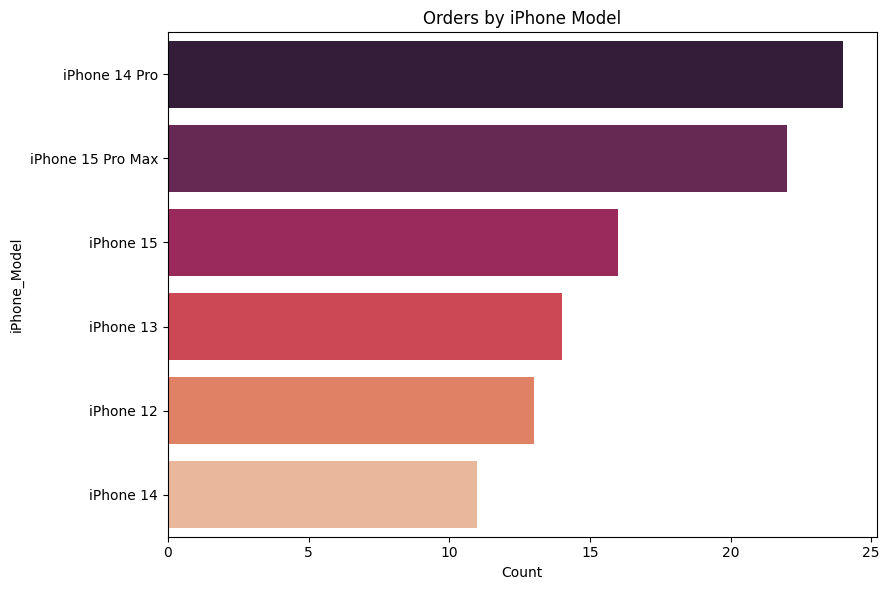

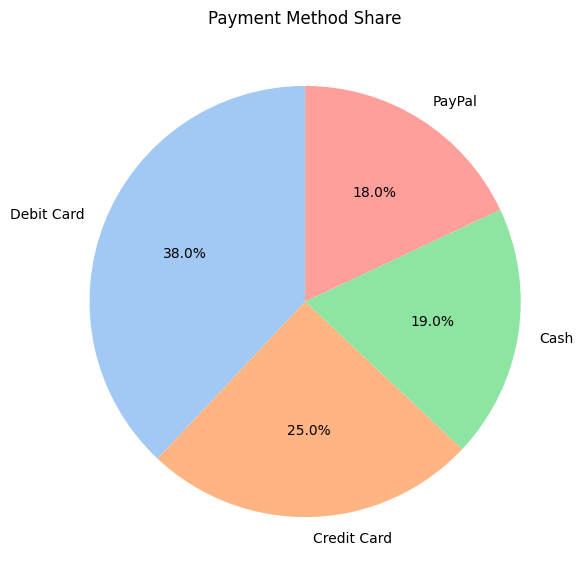

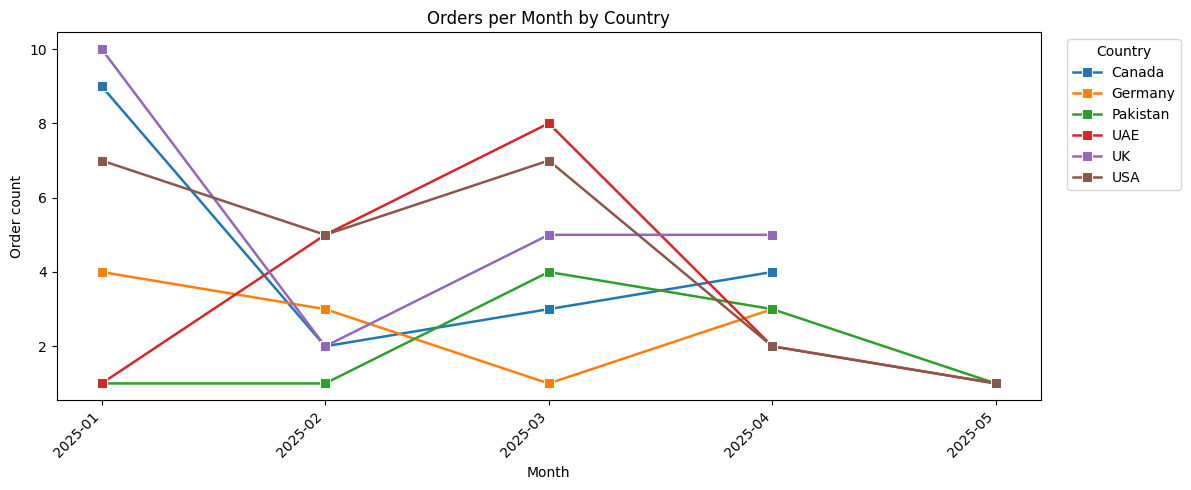

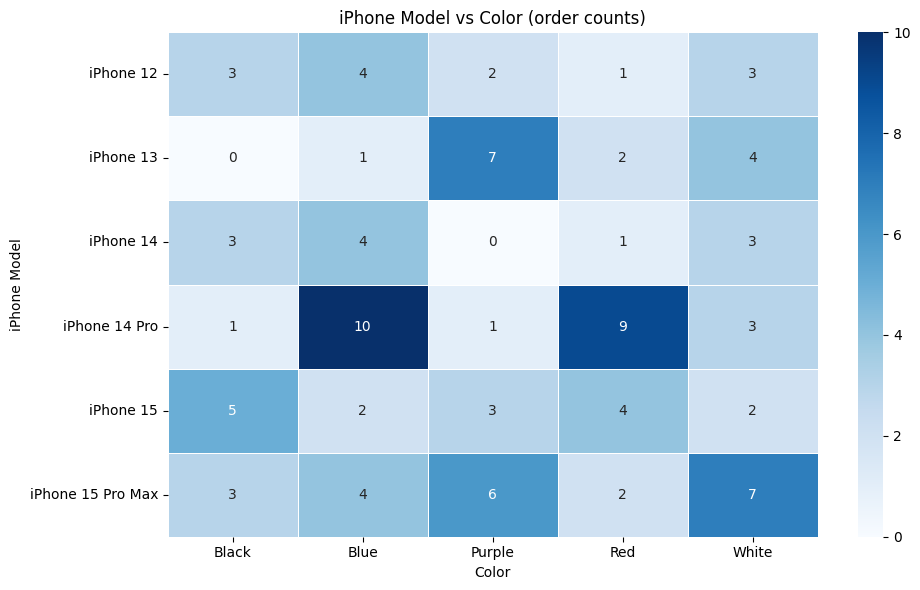

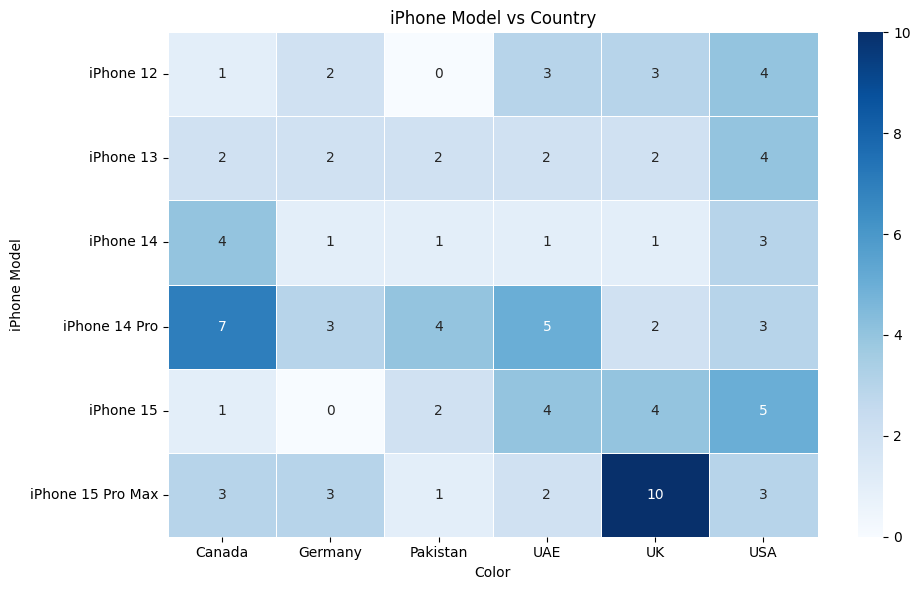

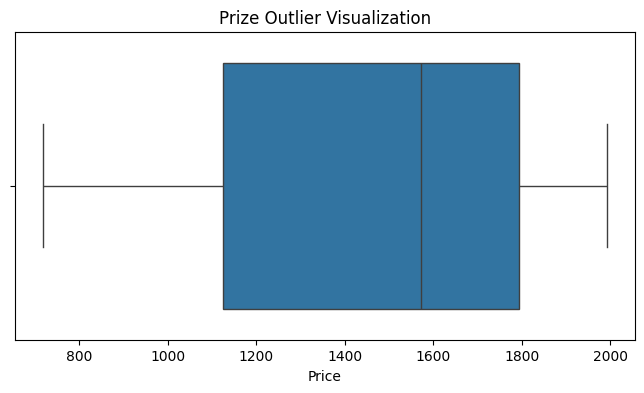

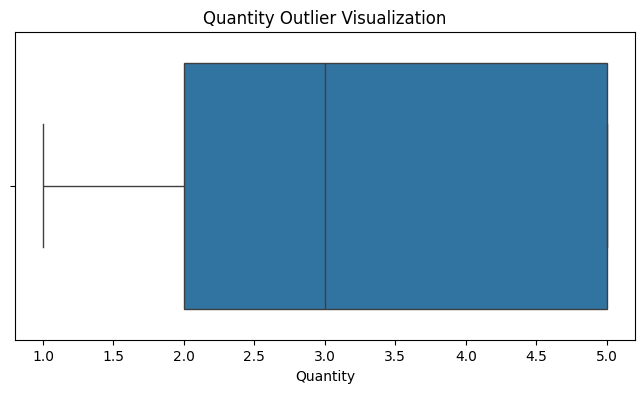

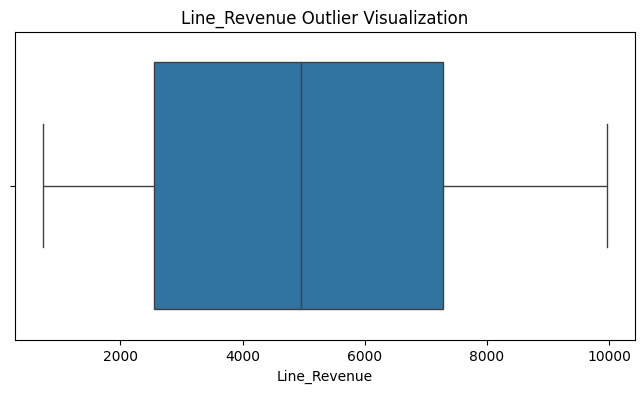

In [31]:
# 1) Revenue by country
revenue_by_country = (
    df.groupby("Country", observed=True)["Line_Revenue"].sum().sort_values(ascending=False).reset_index()
)
fig1, ax1 = plt.subplots(figsize=(9, 5))
sns.barplot(data=revenue_by_country, x="Country", y="Line_Revenue", hue="Country", color="pink", ax=ax1, legend=False)
ax1.set_title("Total Line Revenue by Country")
ax1.set_xlabel("Country")
ax1.set_ylabel("Sum of Quantity × Price")
plt.xticks(rotation=45, ha="right")
fig1.tight_layout()
plt.show()

# 2) Orders per month
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], errors="coerce")
df["YearMonth"] = df["Sale_Date"].dt.to_period("M").astype(str)
monthly = df.groupby("YearMonth", observed=True).size().reset_index(name="orders")
fig2, ax2 = plt.subplots(figsize=(10, 4))
sns.lineplot(data=monthly, x="YearMonth", y="orders", marker="o", ax=ax2, color="darkgreen")
ax2.set_title("Number of Orders per Month")
ax2.set_xlabel("Month")
ax2.set_ylabel("Order count")
plt.xticks(rotation=45, ha="right")
fig2.tight_layout()
plt.show()

# 3) Orders by model
model_counts = df["iPhone_Model"].value_counts().reset_index()
model_counts.columns = ["iPhone_Model", "count"]
fig3, ax3 = plt.subplots(figsize=(9, 6))
sns.barplot(data=model_counts, y="iPhone_Model", x="count", hue="iPhone_Model", palette="rocket", ax=ax3, legend=False)
ax3.set_title("Orders by iPhone Model")
ax3.set_xlabel("Count")
fig3.tight_layout()
plt.show()

    # 4) Payment method distribution
pay = df["Payment_Method"].value_counts()
fig4, ax4 = plt.subplots(figsize=(7, 7))
ax4.pie(pay, labels=pay.index, autopct="%1.1f%%", startangle=90, colors=sns.color_palette("pastel"))
ax4.set_title("Payment Method Share")
plt.show()

# Requires: Sale_Date as datetime (use pd.to_datetime if needed)
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"], errors="coerce")
# Bucket by calendar month (string label for categorical x-axis)
df["YearMonth"] = df["Sale_Date"].dt.to_period("M").astype(str)
# One row per (Country, Month): order counts
monthly_by_country = (
    df.groupby(["Country", "YearMonth"], observed=False)
    .size()
    .reset_index(name="orders")
    .sort_values(["YearMonth", "Country"])
)
fig, ax = plt.subplots(figsize=(12, 5))
sns.lineplot(
    data=monthly_by_country,
    x="YearMonth",
    y="orders",
    hue="Country",
    marker="s",          # square markers at each month (vertices)
    markersize=7,
    linewidth=1.8,
    dashes=False,        # solid lines for every country
    ax=ax,
)
ax.set_title("Orders per Month by Country")
ax.set_xlabel("Month")
ax.set_ylabel("Order count")
plt.xticks(rotation=45, ha="right")
ax.legend(title="Country", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

# Crosstab: rows = model, columns = color, values = order counts
ct = pd.crosstab(df["iPhone_Model"], df["Color"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("iPhone Model vs Color (order counts)")
ax.set_xlabel("Color")
ax.set_ylabel("iPhone Model")
plt.tight_layout()
plt.show()

ct = pd.crosstab(df["iPhone_Model"], df["Country"])

fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="Blues",
    linewidths=0.5,
    ax=ax,
)
ax.set_title("iPhone Model vs Country")
ax.set_xlabel("Color")
ax.set_ylabel("iPhone Model")
plt.tight_layout()
plt.show()

#Boxplots for Outlier Visualization
plt.figure(figsize = (8,4))
sns.boxplot(x=df['Price'])
plt.title("Prize Outlier Visualization")
plt.show()

plt.figure(figsize = (8,4))
sns.boxplot(x=df['Quantity'])
plt.title("Quantity Outlier Visualization")
plt.show()

plt.figure(figsize = (8,4))
sns.boxplot(x=df['Line_Revenue'])
plt.title("Line_Revenue Outlier Visualization")
plt.show()

In [37]:
#IQR METHOD

Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)

IQR = Q1 - Q3

lower= Q1-1.5*IQR
upper= Q3-1.5*IQR

outliers = df[(df['Price']<lower) |
              (df['Price']>upper)] 

print(outliers)

    Order_ID Customer_Name  Country       iPhone_Model Storage   Color  \
0       1001    Customer_1      USA          iPhone 13   256GB  Purple   
1       1002    Customer_2   Canada          iPhone 12   256GB    Blue   
2       1003    Customer_3   Canada  iPhone 15 Pro Max   512GB   Black   
3       1004    Customer_4      USA  iPhone 15 Pro Max   512GB   Black   
4       1005    Customer_5      USA          iPhone 15   128GB    Blue   
..       ...           ...      ...                ...     ...     ...   
95      1096   Customer_96      UAE      iPhone 14 Pro   256GB    Blue   
96      1097   Customer_97       UK  iPhone 15 Pro Max   512GB   White   
97      1098   Customer_98       UK  iPhone 15 Pro Max   512GB   White   
98      1099   Customer_99  Germany  iPhone 15 Pro Max   512GB  Purple   
99      1100  Customer_100       UK          iPhone 15   512GB    Blue   

    Quantity  Price  Sale_Date Payment_Method  Line_Revenue YearMonth  
0          5   1817 2025-05-01     Debi

5. FEATURE ENGINEERING 

In [40]:
df['Month'] = df['Sale_Date'].dt.month
df['Day']= df['Sale_Date'].dt.day
df['Quarter']= df['Sale_Date'].dt.quarter

5. Machine Learning

Objective: Line_Revenue

FEATURES:

- Country
- iPhone_Model
- Storage
- Color
- Quantity
- Price
- Payment_Method

In [41]:
X = df[[ 
'Country',
'iPhone_Model',
'Storage',
'Color',
'Quantity',
'Price',
'Payment_Method']]

y = df['Line_Revenue']


ENCODING

In [47]:
from sklearn.compose import ColumnTransformer 
from sklearn.preprocessing import OneHotEncoder 
preprocessor = ColumnTransformer( 
[ 
('cat', 
OneHotEncoder(handle_unknown='ignore'), 
['Country', 
'iPhone_Model', 
'Storage', 
'Color', 
'Payment_Method']) 
], 
remainder='passthrough'
) 

TRAIN-TEST SPLIT

In [48]:
from sklearn.model_selection import train_test_split 
X_train,X_test,y_train,y_test = train_test_split( 
X,y, 
test_size=0.2, 
random_state=42 
) 


RANDOM FOREST MODEL

In [49]:
from sklearn.pipeline import Pipeline 
from sklearn.ensemble import RandomForestRegressor 
model = Pipeline([ 
('preprocessor',preprocessor), 
('rf',RandomForestRegressor( 
n_estimators=100, 
random_state=42 
)) 
]) 
model.fit(X_train,y_train) 

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['Country', 'iPhone_Model',
                                                   'Storage', 'Color',
                                                   'Payment_Method'])])),
                ('rf', RandomForestRegressor(random_state=42))])

EVALUATION

In [50]:
from sklearn.metrics import r2_score 
predictions = model.predict(X_test) 
print(r2_score(y_test,predictions)) 

0.9795344333537008


SAVE MODEL

In [51]:
import pickle 
pickle.dump( 
model, 
open('iphone_revenue_model.pkl','wb') 
) 

PROJECT STRUCTURE 

- iPhone sales dataset.csv
- iPhone sales model.pkl
- app.py
- requirements.txt
- iPhone sales analysis.ipynb